# 04 — Backward Factor Trace: TinyViT (MNIST even/odd)

**Architecture:** Single-block TinyViT (embed_dim=32, n_heads=2, ffn_dim=64) trained on MNIST even/odd (all 10 digits).  
**BFT layers (forward order):** B0-V (attn, W_V) → B0-O (fc, W_O) → B0-FFN1 (fc) → B0-FFN2 (fc)  
**Sections:**
- §0 Imports & Config
- §1 Models — load/train 5 seeds
- §2 Factorisation & Inspection (seed 0) — BFT, attention spatial grounding, scaffold
- §3 Ablation (all 5 seeds) — comparative sweep, causal circuit ablation
- §4 New Stimuli via NNLS — OOD projection, fingerprint similarity, MDS

## §0  Imports & Config

In [1]:
import sys, os, copy, pickle
sys.path.insert(0, '..')

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torchvision.datasets as datasets
import torchvision.transforms as T
from sklearn.metrics.pairwise import cosine_similarity, paired_cosine_distances
from torch.utils.data import DataLoader, TensorDataset

from src import (
    TinyViT,
    get_mnist_loaders,
    label_transform_even_odd,
    bft,
    build_scaffold_edges, scaffold_loading_from_edges, plot_scaffold_graph,
    extract_tree_nodes, plot_factor_tree, compute_node_activations,
    extract_factor_fingerprint, extract_fingerprint_matrix, compute_stimulus_similarity,
    project_stimuli_onto_tree,
    extract_factor_tree_nodes, compute_factor_activations, nodes_at_layer,
    save_experiment, load_experiment, get_loaders_from_config,
    select_class_circuit, per_class_accuracy,
    plot_factor_overview_panel, plot_factor_gallery, plot_input_layer_factors,
    plot_pruning_results, plot_embedding_comparison,
    compute_nmf_stability, plot_nmf_stability_figure,
    compute_k_sensitivity, plot_k_sensitivity_figure,
    plot_robustness_summary,
)
from src.training import train_epoch, evaluate

torch.manual_seed(42)
np.random.seed(42)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device: {DEVICE}')

# ── Paths ──────────────────────────────────────────────────────────────────────
MODEL_ROOT = '../data/models'
CACHE_ROOT = '../data/cache/nb04_vit'
FIG_DIR    = '../figs/04_vit'
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(CACHE_ROOT, exist_ok=True)

SEED_DIRS = [os.path.join(MODEL_ROOT, f'mnist_even_odd_vit_tiny_seed{s}') for s in range(5)]

# ── Model / BFT hyperparams ────────────────────────────────────────────────────
EMBED_DIM  = 32
N_HEADS    = 2
FFN_DIM    = 64
N_CLASSES  = 2
CLASS_NAMES = {0: 'even', 1: 'odd'}
IMAGE_SIDE  = 28

# k_max and n_branches in FORWARD layer order: [B0-V, B0-O, B0-FFN1, B0-FFN2]
K_MAX      = [10, 6, 6, 4]
N_BRANCHES = [1,  1, 1, 4]
STIM_THRESHOLD = 0.05

N_EPOCHS       = 30
N_SEEDS        = 5
ABLATION_FRACS = [0.05, 0.10, 0.20, 0.30, 0.50]
N_TOP_GALLERY  = 6
USE_CACHED     = True
USE_CACHED_ABL = True

METHODS          = ['bft_top', 'bft_bottom', 'magnitude', 'random']
METHOD_COLORS    = {'bft_top': 'red', 'bft_bottom': 'orange',
                    'magnitude': 'gray', 'random': 'black'}
METHOD_LABELS    = {'bft_top': 'BFT most important', 'bft_bottom': 'BFT least important',
                    'magnitude': 'Highest magnitude', 'random': 'Random'}
N_RANDOM_REPEATS = 5

BASE_CONFIG = {
    'arch': 'TinyViT',
    'arch_kwargs': {
        'embed_dim': EMBED_DIM, 'n_heads': N_HEADS,
        'ffn_dim': FFN_DIM, 'n_classes': N_CLASSES,
    },
    'dataset': 'MNIST',
    'dataset_kwargs': {'root': '../data/', 'batch_size': 64},
    'label_transform': 'even_odd',
}
LABEL_TRANSFORM = label_transform_even_odd
print('Config OK')

device: cuda
Config OK


## §1  Models — 5 seeds

In [2]:
train_loader, test_loader = get_mnist_loaders(batch_size=64, root='../data/')
print(f'Train batches: {len(train_loader)} | Test batches: {len(test_loader)}')

Train batches: 938 | Test batches: 157


In [3]:
def train_vit_seed(seed, seed_dir, n_epochs=N_EPOCHS):
    """Train TinyViT from scratch with Adam, save checkpoint."""
    torch.manual_seed(seed)
    model = TinyViT(embed_dim=EMBED_DIM, n_heads=N_HEADS, ffn_dim=FFN_DIM, n_classes=N_CLASSES).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)
    criterion = nn.NLLLoss()
    best_acc = 0.0

    for epoch in range(n_epochs):
        model.train()
        total_loss = 0.0
        for imgs, digits in train_loader:
            imgs   = imgs.to(DEVICE)
            labels = LABEL_TRANSFORM(digits).to(DEVICE)
            loss   = criterion(model(imgs), labels)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            total_loss += loss.item()
        scheduler.step()

        model.eval()
        n_correct = 0
        with torch.no_grad():
            for imgs, digits in test_loader:
                imgs   = imgs.to(DEVICE)
                labels = LABEL_TRANSFORM(digits).to(DEVICE)
                n_correct += (model(imgs).argmax(1) == labels).sum().item()
        acc = n_correct / len(test_loader.dataset)
        if acc > best_acc:
            best_acc = acc
        if (epoch + 1) % 10 == 0 or epoch == n_epochs - 1:
            print(f'  seed{seed} epoch {epoch+1:3d}/{n_epochs}  '
                  f'loss={total_loss/len(train_loader):.4f}  acc={acc:.4f}')

    cfg = dict(BASE_CONFIG)
    cfg['description'] = f'TinyViT on MNIST even/odd (seed {seed})'
    save_experiment(model, cfg, seed_dir)
    print(f'  → saved to {seed_dir}  best_acc={best_acc:.4f}')
    return model

# Load or train each seed
models = []
for s, seed_dir in enumerate(SEED_DIRS):
    if os.path.exists(os.path.join(seed_dir, 'weights.pt')):
        m, _ = load_experiment(seed_dir, device=DEVICE)
        models.append(m)
        print(f'Loaded seed{s} from {seed_dir}')
    else:
        print(f'Training seed{s} ...')
        m = train_vit_seed(s, seed_dir)
        models.append(m)

print(f'\n{len(models)} models ready.')

Loaded seed0 from ../data/models/mnist_even_odd_vit_tiny_seed0
Loaded seed1 from ../data/models/mnist_even_odd_vit_tiny_seed1
Loaded seed2 from ../data/models/mnist_even_odd_vit_tiny_seed2
Loaded seed3 from ../data/models/mnist_even_odd_vit_tiny_seed3
Loaded seed4 from ../data/models/mnist_even_odd_vit_tiny_seed4

5 models ready.


In [4]:
# Verify test accuracies
for s, model in enumerate(models):
    model.eval()
    n_correct = 0
    with torch.no_grad():
        for imgs, digits in test_loader:
            imgs   = imgs.to(DEVICE)
            labels = LABEL_TRANSFORM(digits).to(DEVICE)
            n_correct += (model(imgs).argmax(1) == labels).sum().item()
    print(f'seed{s}: test acc = {n_correct / len(test_loader.dataset):.4f}')

seed0: test acc = 0.9820
seed1: test acc = 0.9824
seed2: test acc = 0.9812
seed3: test acc = 0.9795
seed4: test acc = 0.9819


## §2  Factorisation & Inspection (seed 0)

BFT traces through all 4 layers of the transformer block in reverse order:
```
B0-FFN2 (root) → B0-FFN1 → B0-O → B0-V (attn, leaf)
```
The attention layer uses an **attention-weighted effective input**:  
$$x^\text{eff}_n = \sum_{j=0}^{T-1} \alpha_{n,j}\, x_{n,j}$$
so each sample is represented by one blended token vector.

In [5]:
def collect_vit_activations(model, loader, device):
    """Collect layer activations and images for correctly-classified samples."""
    model.eval()
    acts = {'attn_in': [], 'attn_w': [], 'attn_out_cls': [], 'ffn1_in': [], 'ffn2_in': []}
    images, targets, digits_all = [], [], []

    with torch.no_grad():
        for imgs, digs in loader:
            imgs   = imgs.to(device)
            labels = label_transform_even_odd(digs).to(device)
            logits = model(imgs, capture=True)
            mask   = (logits.argmax(1) == labels)
            if not mask.any():
                continue
            blk = model.block
            acts['attn_in'].append(blk._attn_in[mask].cpu().numpy())           # (B, 17, 32)
            acts['attn_w'].append(blk._attn_w[mask].mean(1)[:, 0, :].cpu().numpy())  # (B, 17) CLS row
            acts['attn_out_cls'].append(blk._attn_out[mask, 0].cpu().numpy())   # (B, 32)
            acts['ffn1_in'].append(blk._ffn1_in[mask, 0].cpu().numpy())         # (B, 32)
            acts['ffn2_in'].append(blk._ffn2_in[mask, 0].cpu().numpy())         # (B, 64)
            images.append(imgs[mask].cpu().numpy())
            targets.append(labels[mask].cpu().numpy())
            digits_all.append(digs[mask.cpu()].numpy())

    for k in acts:
        acts[k] = np.concatenate(acts[k], axis=0)
    images  = np.concatenate(images,  axis=0)
    targets = np.concatenate(targets, axis=0)
    digits_all = np.concatenate(digits_all, axis=0)
    return acts, images, targets, digits_all


model0 = models[0]
acts0, images0, targets0, digits0 = collect_vit_activations(model0, test_loader, DEVICE)
print(f'Correctly classified: {len(targets0)}')
for k, v in acts0.items():
    print(f'  {k}: {v.shape}')

Correctly classified: 9820
  attn_in: (9820, 17, 32)
  attn_w: (9820, 17)
  attn_out_cls: (9820, 32)
  ffn1_in: (9820, 32)
  ffn2_in: (9820, 64)


In [6]:
D = EMBED_DIM
W_V  = model0.block.attn.in_proj_weight[2*D:, :].detach().cpu().numpy()  # (32, 32)
W_O  = model0.block.attn.out_proj.weight.detach().cpu().numpy()           # (32, 32)
W_f1 = model0.block.ffn1.weight.detach().cpu().numpy()                    # (64, 32)
W_f2 = model0.block.ffn2.weight.detach().cpu().numpy()                    # (32, 64)

layer_dicts0 = [
    {'type': 'attn', 'name': 'B0-V',
     'weight':       W_V,
     'input_fmap':   acts0['attn_in'],        # (N, 17, 32)
     'attn_weights': acts0['attn_w']},         # (N, 17)
    {'type': 'fc', 'name': 'B0-O',
     'weight':    W_O,
     'input_fmap': acts0['attn_out_cls']},     # (N, 32)
    {'type': 'fc', 'name': 'B0-FFN1',
     'weight':    W_f1,
     'input_fmap': acts0['ffn1_in']},          # (N, 32)
    {'type': 'fc', 'name': 'B0-FFN2',
     'weight':    W_f2,
     'input_fmap': acts0['ffn2_in']},          # (N, 64)
]

print('Layer chain (forward order):')
for d in layer_dicts0:
    print(f"  {d['name']:<10} type={d['type']:<5}  W:{str(d['weight'].shape):<12}  "
          f"input:{d['input_fmap'].shape}")

Layer chain (forward order):
  B0-V       type=attn   W:(32, 32)      input:(9820, 17, 32)
  B0-O       type=fc     W:(32, 32)      input:(9820, 32)
  B0-FFN1    type=fc     W:(64, 32)      input:(9820, 32)
  B0-FFN2    type=fc     W:(32, 64)      input:(9820, 64)


In [7]:

tree0 = bft(
    layer_dicts0,
    k_max=K_MAX,
    n_branches=N_BRANCHES,
    stimulus_threshold=STIM_THRESHOLD,
    weighting='img_selectivity',
    verbose=1,
    n_jobs=3,
)



def get_all_paths(root):
    if not root['children']:
        return [[root]]
    return [[root] + p for c in root['children'] for p in get_all_paths(c)]

paths0 = get_all_paths(tree0)
print(f'{len(paths0)} paths from root (B0-FFN2)')
for p in paths0:
    print(f"  path factor-{p[0]['factor_idx']}  layers: "
          + ' → '.join(n['layer_name'] for n in p))

[BFT] Layer 4/4 'B0-FFN2' (fc)  path=[]


/home/jb3879/Factor_Trace/.venv/lib64/python3.11/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


[BFT L4 'B0-FFN2' (fc)]   K=4  t=133.290s
[BFT] Layer 3/4 'B0-FFN1' (fc)  path=[0]


/home/jb3879/Factor_Trace/.venv/lib64/python3.11/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/home/jb3879/Factor_Trace/.venv/lib64/python3.11/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


[BFT L3 'B0-FFN1' (fc)]   K=6  t=421.681s
[BFT] Layer 2/4 'B0-O' (fc)  path=[0, 0]


/home/jb3879/Factor_Trace/.venv/lib64/python3.11/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(


KeyboardInterrupt: 

In [ ]:
# ── Plot 1+4: Factor overview panels & per-factor galleries (all tree nodes) ──
for node in extract_tree_nodes(tree0):
    layer_name = node.get('layer_name', f'L{node["layer_idx"]}')
    figs1 = plot_factor_overview_panel(node, images0, targets0, CLASS_NAMES,
                                        digit_targets=digits0)
    for k, fig in enumerate(figs1):
        fig.savefig(os.path.join(FIG_DIR, f'factor_overview_{layer_name}_k{k}.pdf'),
                    bbox_inches='tight')
        plt.close(fig)
    K = node['img_factors'].shape[1]
    for k in range(K):
        fig4 = plot_factor_gallery(node, images0, targets0, CLASS_NAMES, k=k, n=10)
        fig4.savefig(os.path.join(FIG_DIR, f'factor_gallery_{layer_name}_k{k}.pdf'),
                     bbox_inches='tight')
        plt.close(fig4)

print(f'Plot 1+4 saved for all tree nodes.')

In [ ]:
# ── Plot 2: Attention spatial grounding via plot_input_layer_factors ──────────
def get_attn_nodes(root):
    nodes, queue = [], [root]
    while queue:
        n = queue.pop(0)
        if n['layer_type'] == 'attn':
            nodes.append(n)
        queue.extend(n['children'])
    return nodes

attn_nodes = get_attn_nodes(tree0)
print(f'{len(attn_nodes)} attention (B0-V) nodes in tree')

for attn_node in attn_nodes:
    layer_name = attn_node.get('layer_name', f'L{attn_node["layer_idx"]}')
    figs2 = plot_input_layer_factors(attn_node, images0, arch='attn',
                                      image_shape=(1, IMAGE_SIDE, IMAGE_SIDE))
    for k, fig in enumerate(figs2):
        fig.savefig(os.path.join(FIG_DIR, f'input_factors_{layer_name}_k{k}.pdf'),
                    bbox_inches='tight')
        plt.close(fig)

print(f'Plot 2 saved for {len(attn_nodes)} attention leaf nodes.')

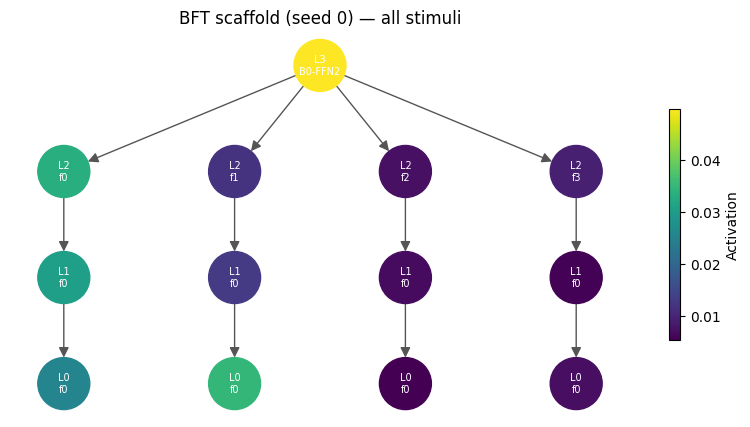

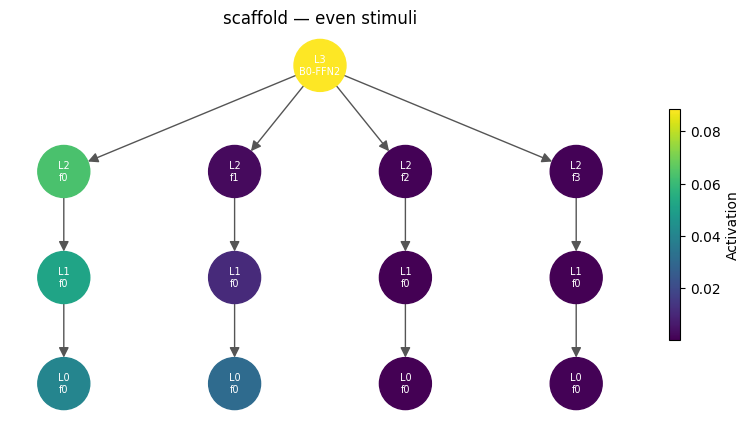

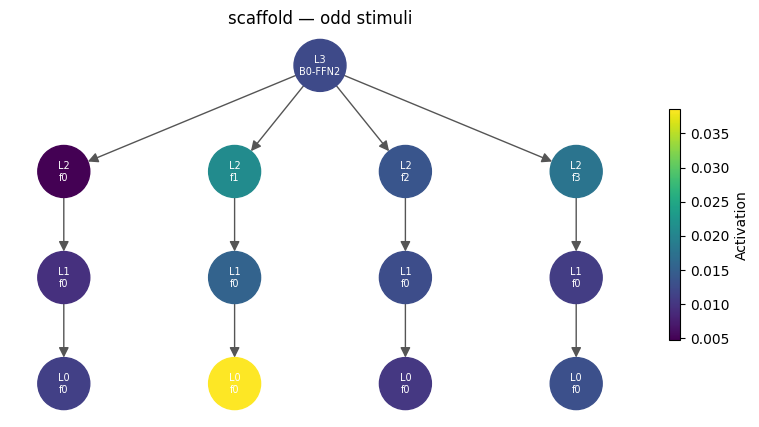

In [ ]:
# ── Scaffold graph ─────────────────────────────────────────────────────────────
tree_nodes0 = extract_tree_nodes(tree0)

fig, ax = plt.subplots(figsize=(10, 5))
node_acts = compute_node_activations(tree_nodes0, list(range(len(targets0))))
plot_factor_tree(tree_nodes0, node_acts, ax=ax, title='BFT scaffold (seed 0) — all stimuli')
fig.savefig(os.path.join(FIG_DIR, 'scaffold_all.png'), dpi=120, bbox_inches='tight')
plt.show()

for cl, cname in enumerate(CLASS_NAMES):
    cl_idx = np.where(targets0 == cl)[0]
    fig, ax = plt.subplots(figsize=(10, 5))
    node_acts_cl = compute_node_activations(tree_nodes0, cl_idx)
    plot_factor_tree(tree_nodes0, node_acts_cl, ax=ax, title=f'scaffold — {cname} stimuli')
    fig.savefig(os.path.join(FIG_DIR, f'scaffold_{cname}.png'), dpi=120, bbox_inches='tight')
    plt.show()

In [ ]:
# ── Plot 5: Robustness ────────────────────────────────────────────────────────
tree_nodes0 = extract_tree_nodes(tree0)

# 5a. NMF init robustness (root node)
print('=== Plot 5a: NMF init robustness (root) ===')
root_X = tree0['img_factors']
k_root = root_X.shape[1]
_p5a = os.path.join(CACHE_ROOT, 'nmf_stab_root.pkl')
if os.path.exists(_p5a):
    with open(_p5a, 'rb') as f: stab5a = pickle.load(f)
else:
    stab5a = compute_nmf_stability(root_X, k_root, n_seeds=10)
    with open(_p5a, 'wb') as f: pickle.dump(stab5a, f)
fig5a = plot_nmf_stability_figure(stab5a, title=f'NMF init robustness — root (K={k_root})')
fig5a.savefig(os.path.join(FIG_DIR, 'nmf_stability_root.pdf'), bbox_inches='tight')
plt.close(fig5a)
print('5a done.')

# 5b. Model-seed robustness (compare root img_factors across 5 seeds)
print('=== Plot 5b: Model-seed robustness ===')
from sklearn.metrics.pairwise import cosine_similarity as _cos_sim
root_factors = [trees_all[s]['img_factors'] for s in range(N_SEEDS)]
K_min = min(f.shape[1] for f in root_factors)
sim_matrix_5b = np.zeros((N_SEEDS, N_SEEDS))
for i in range(N_SEEDS):
    for j in range(N_SEEDS):
        Fi = root_factors[i][:, :K_min]; Fj = root_factors[j][:, :K_min]
        sim_matrix_5b[i, j] = (1.0 if i == j else
                                float(np.mean(np.diag(_cos_sim(Fi.T, Fj.T)))))
fig5b, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(sim_matrix_5b, vmin=0, vmax=1, cmap='RdYlGn')
plt.colorbar(im, ax=ax); ax.set_title('Root factor similarity across 5 model seeds')
ax.set_xlabel('Seed'); ax.set_ylabel('Seed')
plt.tight_layout()
fig5b.savefig(os.path.join(FIG_DIR, 'seed_robustness.pdf'), bbox_inches='tight')
plt.close(fig5b)
off_diag = sim_matrix_5b[~np.eye(N_SEEDS, dtype=bool)].mean()
print(f'5b done. Mean off-diag similarity: {off_diag:.3f}')

# 5c. K-sensitivity (root node, k_star ± 1)
print('=== Plot 5c: K-sensitivity ===')
_p5c = os.path.join(CACHE_ROOT, 'k_sensitivity.pkl')
if os.path.exists(_p5c):
    with open(_p5c, 'rb') as f: ksens = pickle.load(f)
else:
    ksens = compute_k_sensitivity(acts0['ffn2_in'], k_root, n_seeds=5)
    with open(_p5c, 'wb') as f: pickle.dump(ksens, f)
fig5c = plot_k_sensitivity_figure(ksens, title=f'K-sensitivity (root, K*={k_root})')
fig5c.savefig(os.path.join(FIG_DIR, 'k_sensitivity_root.pdf'), bbox_inches='tight')
plt.close(fig5c)
print('5c done.')

# 5d. Dataset-split robustness (two random 50/50 splits)
print('=== Plot 5d: Dataset-split robustness ===')
_p5d = os.path.join(CACHE_ROOT, 'split_robustness.pkl')
if os.path.exists(_p5d):
    with open(_p5d, 'rb') as f: split_rob = pickle.load(f)
else:
    n = len(targets0)
    rng_sp = np.random.default_rng(77)
    perm = rng_sp.permutation(n); half = n // 2
    A_idx, B_idx = perm[:half], perm[half:]
    def _split_ld(base_ld, idx):
        res = []
        for ld in base_ld:
            if isinstance(ld, dict):
                res.append({k2: (v[idx] if isinstance(v, np.ndarray) and len(v) == n else v)
                             for k2, v in ld.items()})
            else:
                res.append(ld[idx] if isinstance(ld, np.ndarray) and len(ld) == n else ld)
        return res
    ldA = _split_ld(layer_dicts0, A_idx)
    ldB = _split_ld(layer_dicts0, B_idx)
    root_A = bft(ldA, k_max=K_MAX, n_branches=N_BRANCHES,
                  stimulus_threshold=STIM_THRESHOLD, n_jobs=3)
    root_B = bft(ldB, k_max=K_MAX, n_branches=N_BRANCHES,
                  stimulus_threshold=STIM_THRESHOLD, n_jobs=3)
    FA = root_A['img_factors']; FB = root_B['img_factors']
    K_ab = min(FA.shape[1], FB.shape[1])
    sim_split = float(np.mean(np.diag(_cos_sim(FA[:, :K_ab].T, FB[:, :K_ab].T))))
    split_rob = {'sim': sim_split, 'K_ab': K_ab}
    with open(_p5d, 'wb') as f: pickle.dump(split_rob, f)
print(f'5d done. Root factor similarity across 50/50 splits: {split_rob["sim"]:.3f}')
print('\nPlot 5 complete.')

## §3  Ablation (all 5 seeds)

Local ablation helpers for TinyViT (standard `ablation_utils` depend on `model.linear_layer_indices()`,  
which is SimpleMLP-specific). We ablate the FFN and output-projection weights only.

In [ ]:
# ── ViT ablation helpers ──────────────────────────────────────────────────────
VIT_LINEAR_KEYS = [
    'block.attn.out_proj.weight',
    'block.ffn1.weight',
    'block.ffn2.weight',
    'head.weight',
]
_LAYER_IDX_TO_KEY = {
    1: 'block.attn.out_proj.weight',
    2: 'block.ffn1.weight',
    3: 'block.ffn2.weight',
}


def vit_score_nmf(path_nodes):
    """NMF importance: {param_key: (n_out, n_in) array}."""
    scores = {}
    for node in path_nodes:
        key = _LAYER_IDX_TO_KEY.get(node['layer_idx'])
        if key is None:
            continue
        W = node['W']
        n_out, n_in = W.shape
        importance = np.zeros((n_out, n_in))
        for k in range(node['neural_factors'].shape[1]):
            nf = node['neural_factors'][:, k].reshape(n_out, n_in)
            importance += node['lambdas'][k] * nf
        scores[key] = importance
    return scores


def vit_score_magnitude(model):
    """Magnitude importance: {param_key: |W|}."""
    params = dict(model.named_parameters())
    return {key: np.abs(params[key].data.cpu().numpy()) for key in VIT_LINEAR_KEYS}


def vit_ablate(model, scores, frac, method='top', seed=42):
    """Zero the top-fraction of weights by score; returns a deep copy."""
    m = copy.deepcopy(model)
    params = dict(m.named_parameters())
    for key, imp in scores.items():
        if key not in params:
            continue
        flat_imp = imp.flatten()
        n_abl = max(1, int(len(flat_imp) * frac))
        if method == 'top':
            idx = np.argsort(flat_imp)[::-1][:n_abl].copy()
        elif method == 'bottom':
            idx = np.argsort(flat_imp)[:n_abl].copy()
        elif method == 'magnitude':
            pw = np.abs(params[key].data.cpu().numpy().flatten())
            idx = np.argsort(pw)[::-1][:n_abl].copy()
        elif method == 'random':
            rng = np.random.default_rng(seed)
            idx = rng.choice(len(flat_imp), n_abl, replace=False)
        else:
            raise ValueError(method)
        with torch.no_grad():
            params[key].data.view(-1)[torch.from_numpy(np.ascontiguousarray(idx))] = 0.0
    return m


def vit_select_class_circuit(tree_root, targets, class_d):
    """Select vit_score_nmf scores for the factor path most selective for class_d."""
    img_factors = tree_root['img_factors']
    K = img_factors.shape[1]
    tgt = np.asarray(targets)
    mask_d = (tgt == class_d)
    sels = []
    for k in range(K):
        mean_d = float(img_factors[mask_d, k].mean()) if mask_d.any() else 0.0
        mean_o = float(img_factors[~mask_d, k].mean()) if (~mask_d).any() else 0.0
        sels.append(mean_d / (mean_o + 1e-6))
    k_star = int(np.argmax(sels))
    # Find child following factor k_star
    children = tree_root.get('children', [])
    child = next((c for c in children if c.get('factor_idx', -1) == k_star), None)
    if child is None and children:
        child = children[0]
    path_nodes = [tree_root]
    node = child
    while node is not None:
        path_nodes.append(node)
        node = node['children'][0] if node.get('children') else None
    return vit_score_nmf(path_nodes), {'k_star': k_star, 'selectivity': sels[k_star]}


def eval_per_class_vit(model, loader, device):
    """Return per-class accuracy dict {class_idx: float}."""
    model.eval()
    correct = {c: 0 for c in range(N_CLASSES)}
    total   = {c: 0 for c in range(N_CLASSES)}
    with torch.no_grad():
        for imgs, digits in loader:
            imgs   = imgs.to(device)
            labels = label_transform_even_odd(digits)
            preds  = model(imgs).argmax(1).cpu()
            for c in range(N_CLASSES):
                mask = labels == c
                correct[c] += (preds[mask] == labels[mask]).sum().item()
                total[c]   += mask.sum().item()
    return {c: correct[c] / total[c] if total[c] > 0 else 0.0 for c in range(N_CLASSES)}


base_acc = eval_per_class_vit(model0, test_loader, DEVICE)
print('Baseline per-class accuracy (seed 0):')
for c, name in CLASS_NAMES.items():
    print(f'  {name}: {base_acc[c]:.4f}')

In [ ]:
# ── Cache BFT for all 5 seeds ──────────────────────────────────────────────────
trees_all = [tree0]
acts_all  = [acts0]

for s in range(1, 5):
    cache_f = os.path.join(CACHE_ROOT, f'bft_seed{s}.pkl')
    if USE_CACHED and os.path.exists(cache_f):
        with open(cache_f, 'rb') as f:
            tree_s = pickle.load(f)
        print(f'Loaded BFT seed{s} from cache.')
    else:
        acts_s, _, _, _ = collect_vit_activations(models[s], test_loader, DEVICE)
        D = EMBED_DIM
        W_V_s  = models[s].block.attn.in_proj_weight[2*D:, :].detach().cpu().numpy()
        W_O_s  = models[s].block.attn.out_proj.weight.detach().cpu().numpy()
        W_f1_s = models[s].block.ffn1.weight.detach().cpu().numpy()
        W_f2_s = models[s].block.ffn2.weight.detach().cpu().numpy()
        ld_s = [
            {'type': 'attn', 'name': 'B0-V',    'weight': W_V_s,  'input_fmap': acts_s['attn_in'],      'attn_weights': acts_s['attn_w']},
            {'type': 'fc',   'name': 'B0-O',    'weight': W_O_s,  'input_fmap': acts_s['attn_out_cls']},
            {'type': 'fc',   'name': 'B0-FFN1', 'weight': W_f1_s, 'input_fmap': acts_s['ffn1_in']},
            {'type': 'fc',   'name': 'B0-FFN2', 'weight': W_f2_s, 'input_fmap': acts_s['ffn2_in']},
        ]
        print(f'Running BFT seed{s} ...')
        tree_s = bft(ld_s, k_max=K_MAX, n_branches=N_BRANCHES,
                     stimulus_threshold=STIM_THRESHOLD, weighting='img_selectivity',
                     verbose=0, n_jobs=3)
        with open(cache_f, 'wb') as f:
            pickle.dump(tree_s, f)
        print(f'  seed{s} done, cached.')
    trees_all.append(tree_s)
    # re-collect acts for ablation if needed
    acts_all.append(None)  # placeholder — loaded only for BFT

print(f'Trees ready: {len(trees_all)}')

Running BFT seed1 ...


/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/Users/johannesbertram/repos/Weight_Interpre

  seed1 done, cached.
Running BFT seed2 ...


/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/Users/johannesbertram/repos/Weight_Interpre

  seed2 done, cached.
Running BFT seed3 ...


/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/Users/johannesbertram/repos/Weight_Interpre

  seed3 done, cached.
Running BFT seed4 ...


/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/Users/johannesbertram/repos/Weight_Interpretability/.venv/lib/python3.13/site-packages/sklearn/decomposition/_nmf.py:2306: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/Users/johannesbertram/repos/Weight_Interpre

  seed4 done, cached.
Trees ready: 5


In [ ]:
# ── Plot 6: Ablation sweep — BFT vs magnitude vs random (all 5 seeds) ─────────
ABL_CACHE = os.path.join(CACHE_ROOT, 'plot6_ablation.pkl')

if USE_CACHED_ABL and os.path.exists(ABL_CACHE):
    with open(ABL_CACHE, 'rb') as f:
        pruning_raw = pickle.load(f)
    print(f'Loaded Plot 6 ablation from cache ({len(pruning_raw)} seeds).')
else:
    pruning_raw = []

    for s in range(N_SEEDS):
        print(f'\n=== Seed {s} ===')
        model_s = models[s]
        tree_s  = trees_all[s]
        # Collect targets for this seed (correctly classified)
        _, _, targets_s, _ = collect_vit_activations(model_s, test_loader, DEVICE)
        mag_scores = vit_score_magnitude(model_s)
        seed_res = {d: {m: {f: {} for f in ABLATION_FRACS} for m in METHODS}
                    for d in range(N_CLASSES)}

        for d in range(N_CLASSES):
            print(f'  class {d} ({CLASS_NAMES[d]})', end=' ', flush=True)
            imp_scores, _ = vit_select_class_circuit(tree_s, targets_s, d)

            for frac in ABLATION_FRACS:
                abl = vit_ablate(model_s, imp_scores, frac, 'top')
                seed_res[d]['bft_top'][frac] = eval_per_class_vit(abl, test_loader, DEVICE)
                abl = vit_ablate(model_s, imp_scores, frac, 'bottom')
                seed_res[d]['bft_bottom'][frac] = eval_per_class_vit(abl, test_loader, DEVICE)
                abl = vit_ablate(model_s, mag_scores, frac, 'top')
                seed_res[d]['magnitude'][frac] = eval_per_class_vit(abl, test_loader, DEVICE)
                rand_accs = [eval_per_class_vit(
                    vit_ablate(model_s, imp_scores, frac, 'random', seed=rep),
                    test_loader, DEVICE) for rep in range(N_RANDOM_REPEATS)]
                seed_res[d]['random'][frac] = {c: float(np.mean([a.get(c, 0) for a in rand_accs]))
                                               for c in range(N_CLASSES)}
            print('done')

        pruning_raw.append(seed_res)

    with open(ABL_CACHE, 'wb') as f:
        pickle.dump(pruning_raw, f)
    print('\nPlot 6 ablation complete and cached.')

# Aggregate across seeds
pruning_data = {d: {m: {f: {} for f in ABLATION_FRACS} for m in METHODS} for d in range(N_CLASSES)}
pruning_stds = {d: {m: {f: {} for f in ABLATION_FRACS} for m in METHODS} for d in range(N_CLASSES)}
for d in range(N_CLASSES):
    for m in METHODS:
        for f in ABLATION_FRACS:
            for c in range(N_CLASSES):
                vals = [pruning_raw[s][d][m][f].get(c, 0.0) for s in range(len(pruning_raw))]
                pruning_data[d][m][f][c] = float(np.mean(vals))
                pruning_stds[d][m][f][c] = float(np.std(vals))

print('Aggregated. Classes:', list(pruning_data.keys()))

In [ ]:
# ── Plot 6 display ─────────────────────────────────────────────────────────────
baseline = eval_per_class_vit(model0, test_loader, DEVICE)
for d in range(N_CLASSES):
    for m in METHODS:
        pruning_data[d][m][0.0] = dict(baseline)
        pruning_stds[d][m][0.0] = {c: 0.0 for c in range(N_CLASSES)}

fracs_plot = [0.0] + ABLATION_FRACS
figs6 = plot_pruning_results(
    pruning_data, CLASS_NAMES, METHODS, fracs_plot,
    method_colors=METHOD_COLORS, method_labels=METHOD_LABELS,
    pruning_stds=pruning_stds,
)
for d, fig in enumerate(figs6):
    fig.savefig(os.path.join(FIG_DIR, f'pruning_{CLASS_NAMES[d]}.pdf'), bbox_inches='tight')
    plt.show()
    plt.close(fig)
print(f'Saved {len(figs6)} pruning figures.')

## §4  New Stimuli via NNLS

`project_stimuli_onto_tree` re-uses the fixed NMF bases from seed 0's BFT tree  
and projects new stimuli onto them via backward-weighted NNLS.  
For the attention layer (B0-V) the input must be supplied as a dict  
`{'x_tokens': (N,T,d), 'attn_weights': (N,T)}`.

In [ ]:
def collect_vit_layer_inputs(model, loader, device, only_correct=True, max_per_class=None):
    """Collect layer inputs for new_layer_inputs passed to project_stimuli_onto_tree.

    Returns (new_layer_inputs, images, targets, digits) where new_layer_inputs is
    a list of 4 items in FORWARD order:
      [0] dict {'x_tokens': (N,17,32), 'attn_weights': (N,17)}   — attn layer
      [1] ndarray (N, 32)  — B0-O fc layer
      [2] ndarray (N, 32)  — B0-FFN1
      [3] ndarray (N, 64)  — B0-FFN2
    """
    model.eval()
    acts = {'attn_in': [], 'attn_w': [], 'attn_out': [], 'ffn1_in': [], 'ffn2_in': []}
    images, targets_l, digits_l = [], [], []
    counts = {c: 0 for c in range(N_CLASSES)}

    with torch.no_grad():
        for imgs, digs in loader:
            imgs   = imgs.to(device)
            labels = label_transform_even_odd(digs)
            logits = model(imgs, capture=True)
            preds  = logits.argmax(1).cpu()

            if only_correct:
                mask = (preds == labels)
            else:
                mask = torch.ones(len(labels), dtype=torch.bool)

            if max_per_class is not None:
                for c in range(N_CLASSES):
                    if counts[c] >= max_per_class:
                        mask &= ~(labels == c)

            if not mask.any():
                continue

            blk = model.block
            acts['attn_in'].append(blk._attn_in[mask].cpu().numpy())
            acts['attn_w'].append(blk._attn_w[mask].mean(1)[:, 0, :].cpu().numpy())
            acts['attn_out'].append(blk._attn_out[mask, 0].cpu().numpy())
            acts['ffn1_in'].append(blk._ffn1_in[mask, 0].cpu().numpy())
            acts['ffn2_in'].append(blk._ffn2_in[mask, 0].cpu().numpy())
            images.append(imgs[mask].cpu().numpy())
            targets_l.append(labels[mask].numpy())
            digits_l.append(digs[mask.cpu()].numpy())
            for c in range(N_CLASSES):
                counts[c] += (labels[mask] == c).sum().item()

    for k in acts:
        acts[k] = np.concatenate(acts[k], axis=0)

    new_layer_inputs = [
        {'x_tokens': acts['attn_in'], 'attn_weights': acts['attn_w']},  # idx 0 = B0-V
        acts['attn_out'],    # idx 1 = B0-O
        acts['ffn1_in'],     # idx 2 = B0-FFN1
        acts['ffn2_in'],     # idx 3 = B0-FFN2
    ]
    images    = np.concatenate(images,    axis=0)
    targets_l = np.concatenate(targets_l, axis=0)
    digits_l  = np.concatenate(digits_l,  axis=0)
    return new_layer_inputs, images, targets_l, digits_l


def collect_vit_ood_inputs(model, loader, device, n_max=2000):
    """Collect activations for OOD data (no label filtering)."""
    model.eval()
    acts = {'attn_in': [], 'attn_w': [], 'attn_out': [], 'ffn1_in': [], 'ffn2_in': []}
    images_l = []
    n_seen = 0

    with torch.no_grad():
        for imgs, _ in loader:
            if n_seen >= n_max:
                break
            imgs = imgs.to(device)
            _ = model(imgs, capture=True)
            blk = model.block
            b = min(len(imgs), n_max - n_seen)
            acts['attn_in'].append(blk._attn_in[:b].cpu().numpy())
            acts['attn_w'].append(blk._attn_w[:b].mean(1)[:, 0, :].cpu().numpy())
            acts['attn_out'].append(blk._attn_out[:b, 0].cpu().numpy())
            acts['ffn1_in'].append(blk._ffn1_in[:b, 0].cpu().numpy())
            acts['ffn2_in'].append(blk._ffn2_in[:b, 0].cpu().numpy())
            images_l.append(imgs[:b].cpu().numpy())
            n_seen += b

    for k in acts:
        acts[k] = np.concatenate(acts[k], axis=0)
    new_layer_inputs = [
        {'x_tokens': acts['attn_in'], 'attn_weights': acts['attn_w']},
        acts['attn_out'], acts['ffn1_in'], acts['ffn2_in'],
    ]
    images_l = np.concatenate(images_l, axis=0)
    return new_layer_inputs, images_l


print('NNLS helpers defined.')

In [ ]:
# ── Round-trip test (print Pearson r — no plot) ────────────────────────────────
new_inputs_test, _, _, _ = collect_vit_layer_inputs(model0, test_loader, DEVICE, only_correct=True)
tree_rt = project_stimuli_onto_tree(tree0, new_inputs_test)
orig_f = tree0['img_factors']
nnls_f = tree_rt['img_factors']
N_cmp = min(len(orig_f), len(nnls_f))
K_cmp = min(orig_f.shape[1], nnls_f.shape[1])
corrs = [np.corrcoef(orig_f[:N_cmp, k], nnls_f[:N_cmp, k])[0, 1] for k in range(K_cmp)]
print('Round-trip Pearson r per root factor:')
for k, r in enumerate(corrs):
    print(f'  factor {k}: r={r:.4f}')
print(f'  mean r = {np.mean(corrs):.4f}')

In [ ]:
# ── Near-OOD: Fashion-MNIST ────────────────────────────────────────────────────
fmnist_loader = DataLoader(
    datasets.FashionMNIST('../data/', train=False, download=True, transform=T.ToTensor()),
    batch_size=64, shuffle=False,
)
FMNIST_CLASSES = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
                  'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Boot']

_p_ood = os.path.join(CACHE_ROOT, 'near_ood_fmnist.pkl')
if USE_CACHED and os.path.exists(_p_ood):
    with open(_p_ood, 'rb') as f: _d = pickle.load(f)
    new_inputs_fmnist = _d['nli']; images_fmnist = _d['images']
else:
    new_inputs_fmnist, images_fmnist = collect_vit_ood_inputs(model0, fmnist_loader, DEVICE, n_max=2000)
    with open(_p_ood, 'wb') as f:
        pickle.dump({'nli': new_inputs_fmnist, 'images': images_fmnist}, f)

tree_fmnist = project_stimuli_onto_tree(tree0, new_inputs_fmnist)
print(f'Fashion-MNIST OOD: {images_fmnist.shape[0]} samples projected.')

In [ ]:
# ── Far-OOD projections ────────────────────────────────────────────────────────
N_FAR = 500

def make_far_ood(n=N_FAR):
    return {
        'gaussian':    torch.clamp(torch.randn(n, 1, 28, 28) * 0.3 + 0.5, 0, 1),
        'uniform':     torch.zeros(n, 1, 28, 28) + 0.5,
        'checkerboard': torch.tensor(
            np.tile([[0, 1], [1, 0]], (n, 1, 14, 14)).astype(np.float32)),
        'inverted':    1.0 - torch.stack([test_loader.dataset[i][0] for i in range(n)]),
    }

far_ood_tensors = make_far_ood()

far_trees = {}
for ood_name, tensor in far_ood_tensors.items():
    ood_loader = DataLoader(
        TensorDataset(tensor, torch.zeros(N_FAR, dtype=torch.long)),
        batch_size=64,
    )
    nli, imgs_far = collect_vit_ood_inputs(model0, ood_loader, DEVICE, n_max=N_FAR)
    projected = project_stimuli_onto_tree(tree0, nli)
    far_trees[ood_name] = {'projected': projected, 'images': imgs_far, 'nli': nli}
    print(f'{ood_name}: {imgs_far.shape[0]} samples projected')

In [ ]:
# ── Fingerprint similarity matrix ─────────────────────────────────────────────
N_FP = 100

conditions = {
    'even (ID)':    (tree0,        np.where(targets0 == 0)[0][:N_FP]),
    'odd (ID)':     (tree0,        np.where(targets0 == 1)[0][:N_FP]),
    'FashionMNIST': (tree_fmnist,  np.arange(N_FP)),
    'gaussian':     (far_trees['gaussian']['projected'],     np.arange(N_FP)),
    'uniform':      (far_trees['uniform']['projected'],      np.arange(N_FP)),
    'checkerboard': (far_trees['checkerboard']['projected'], np.arange(N_FP)),
    'inverted':     (far_trees['inverted']['projected'],     np.arange(N_FP)),
}

fp_matrices = {cname: extract_fingerprint_matrix(tree_c, idx_c)
               for cname, (tree_c, idx_c) in conditions.items()}

cond_names = list(conditions.keys())
n_conds    = len(cond_names)
sim_matrix = np.zeros((n_conds, n_conds))
for i, ci in enumerate(cond_names):
    for j, cj in enumerate(cond_names):
        S = cosine_similarity(fp_matrices[ci], fp_matrices[cj])
        sim_matrix[i, j] = S.mean()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(sim_matrix, cmap='viridis', vmin=0, vmax=1)
ax.set_xticks(range(n_conds)); ax.set_xticklabels(cond_names, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(n_conds)); ax.set_yticklabels(cond_names, fontsize=9)
plt.colorbar(im, ax=ax, label='mean cosine similarity')
for i in range(n_conds):
    for j in range(n_conds):
        ax.text(j, i, f'{sim_matrix[i, j]:.2f}', ha='center', va='center',
                color='white' if sim_matrix[i, j] < 0.5 else 'black', fontsize=7)
ax.set_title('BFT fingerprint similarity matrix', fontsize=11)
plt.tight_layout()
fig.savefig(os.path.join(FIG_DIR, 'fingerprint_sim_matrix.pdf'), dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
# ── Plot 7: 3-panel embedding comparison ──────────────────────────────────────
N_EACH = 100; rng_m = np.random.default_rng(7)

F_parts, la_parts, emb_labels, emb_digits, emb_conds = [], [], [], [], []

# ID MNIST even/odd
id_sub = rng_m.choice(len(targets0), min(N_EACH * 2, len(targets0)), replace=False)
F_parts.append(np.concatenate([fp_matrices['even (ID)'], fp_matrices['odd (ID)']], axis=0))
la_parts.append(np.vstack([
    np.array([acts0['ffn2_in'][i] for i in np.where(targets0 == 0)[0][:N_FP]]),
    np.array([acts0['ffn2_in'][i] for i in np.where(targets0 == 1)[0][:N_FP]]),
]))
emb_labels.extend(targets0[np.where(targets0 == 0)[0][:N_FP]].tolist() +
                   targets0[np.where(targets0 == 1)[0][:N_FP]].tolist())
emb_digits.extend(digits0[np.where(targets0 == 0)[0][:N_FP]].tolist() +
                   digits0[np.where(targets0 == 1)[0][:N_FP]].tolist())
emb_conds.extend(['ID'] * (2 * N_FP))

# Near-OOD Fashion-MNIST
F_parts.append(fp_matrices['FashionMNIST'])
la_parts.append(np.array([new_inputs_fmnist[-1][i] for i in range(N_FP)]))
emb_labels.extend([2] * N_FP)
emb_digits.extend([-1] * N_FP)
emb_conds.extend(['FashionMNIST'] * N_FP)

# Far-OOD (first type only for clarity)
for ood_name in list(far_trees.keys())[:2]:
    d = far_trees[ood_name]
    F_parts.append(fp_matrices[ood_name])
    la_parts.append(np.array([d['nli'][-1][i] for i in range(min(N_FP, len(d['nli'][-1])))]))
    n = len(F_parts[-1])
    emb_labels.extend([3] * n)
    emb_digits.extend([-1] * n)
    emb_conds.extend([ood_name] * n)

F_joint = np.concatenate(F_parts, axis=0)
la_joint = np.vstack(la_parts)
emb_labels = np.array(emb_labels)
emb_digits = np.array(emb_digits)

full_class_names = {0: 'even', 1: 'odd', 2: 'FashionMNIST', 3: 'far-OOD'}
fig7 = plot_embedding_comparison(
    F_joint, la_joint, emb_labels, full_class_names,
    condition_labels=emb_conds, title='MNIST even/odd — ID / Near-OOD / Far-OOD')
fig7.savefig(os.path.join(FIG_DIR, 'embedding_comparison.pdf'), bbox_inches='tight')
plt.show(); plt.close(fig7)

# Intra vs inter-class similarity histogram
F_id = np.concatenate([fp_matrices['even (ID)'], fp_matrices['odd (ID)']], axis=0)
lbl_id = np.array([0] * N_FP + [1] * N_FP)
S_id = cosine_similarity(F_id)
intra_vals, inter_vals = [], []
for ci in range(N_CLASSES):
    mask = lbl_id == ci
    intra = S_id[np.ix_(mask, mask)]
    intra_vals.extend(intra[np.triu_indices_from(intra, k=1)])
    for cj in range(ci + 1, N_CLASSES):
        inter_vals.extend(S_id[np.ix_(mask, lbl_id == cj)].ravel())
intra_arr, inter_arr = np.array(intra_vals), np.array(inter_vals)
print(f'Intra-class: {intra_arr.mean():.3f} ± {intra_arr.std():.3f}')
print(f'Inter-class: {inter_arr.mean():.3f} ± {inter_arr.std():.3f}')
fig_ii, ax = plt.subplots(figsize=(6, 4))
ax.hist(intra_arr, bins=50, alpha=0.6, label='Intra-class', density=True)
ax.hist(inter_arr, bins=50, alpha=0.6, label='Inter-class', density=True)
ax.axvline(intra_arr.mean(), color='C0', ls='--'); ax.axvline(inter_arr.mean(), color='C1', ls='--')
ax.set(xlabel='Cosine similarity', ylabel='Density',
       title='Factor fingerprint: intra vs inter-class')
ax.legend(); plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, 'fingerprint_intra_inter.pdf'), bbox_inches='tight')
plt.show(); plt.close(fig_ii)